# Part reco $KK\pi\pi$ kaon energy
## Make plots of kaon energies for signal and background

### Remove statistics box

In [1]:
gStyle->SetOptStat(0);

### Load signal sample

In [2]:
TChain SignalChain("KSpipiPartRecoDoubleTag");
std::string SignalPath("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/Tuples/SignalMC/DoubleTag/");
SignalPath += "KKpipiVersusKSpipi/KKpipiVersusKSpipiDoubleTagMCSignal*.root";
SignalChain.Add(SignalPath.c_str());

### Signal histogram

In [3]:
TH1D Signal_hist("Signal_hist", "", 100, 0.4, 1.0);
Signal_hist.SetLineColor(kBlue);
Signal_hist.SetLineWidth(3);
Signal_hist.SetTitle("Comparison of kaon energies between KK#pi#pi and K#pi#pi#pi#pi^{0};Energy (GeV);Normalised entries");
SignalChain.Draw("SignalKPlusenergy >> Signal_hist", "", "GOFF NORM");

### Load background sample

In [4]:
TChain BackgroundChain("KSpipiPartRecoDoubleTag");
std::string BackgroundPath("/data/bes3/tat/KKpipi_StrongPhase_Analysis/PeakingBackgroundStudies/");
BackgroundPath += "KSpipiPartRecoDoubleTag/KSpipiPartRecoDoubleTag.root";
BackgroundChain.Add(BackgroundPath.c_str());

### Background histogram

In [5]:
TH1D Background_hist("Background_hist", "", 100, 0.4, 1.0);
Background_hist.SetLineColor(kRed);
Background_hist.SetLineWidth(3);
BackgroundChain.Draw("SignalKPlusenergy >> Background_hist", "", "GOFF NORM");

### Plot histograms

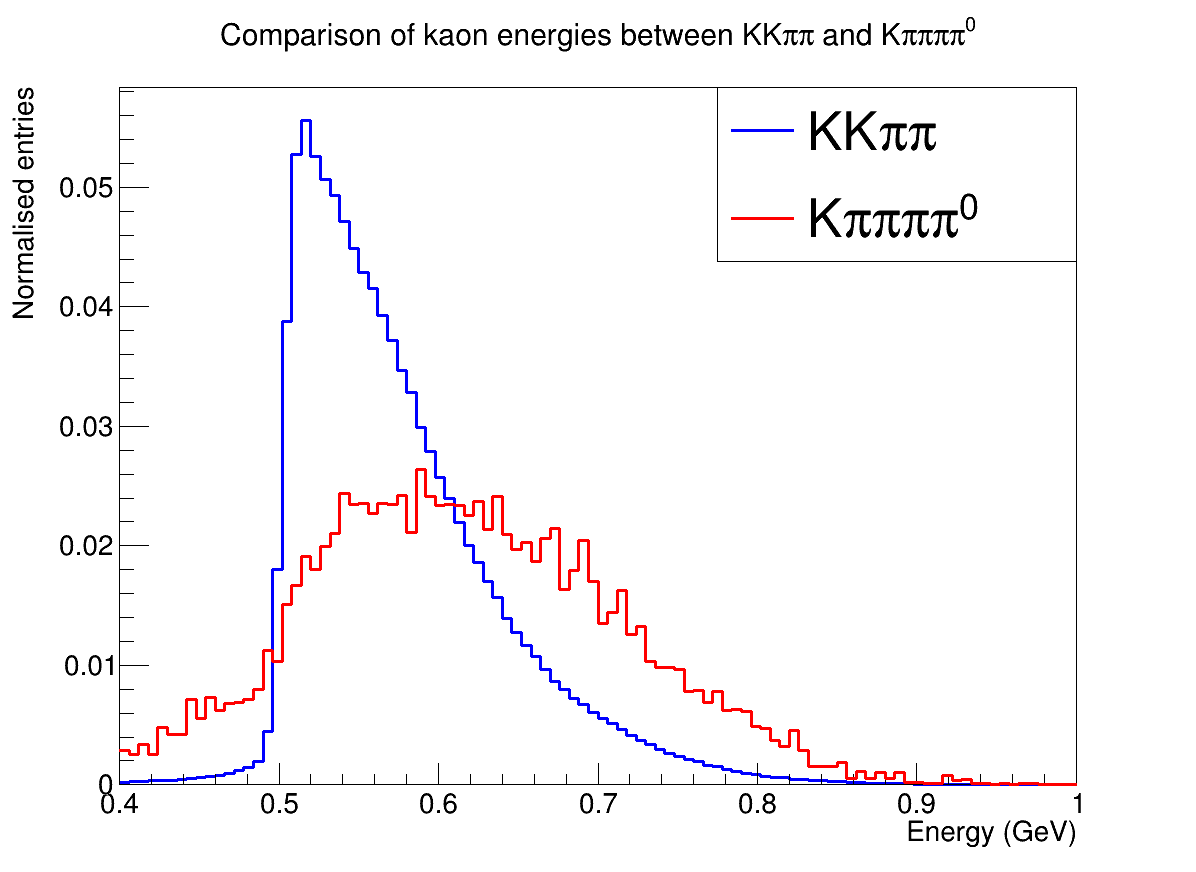

Info in <TCanvas::Print>: pdf file Kaon_energy_comparison_Kpipipipi0.pdf has been created


In [6]:
TCanvas c("c", "", 1200, 900);
Signal_hist.Draw("HIST");
Background_hist.Draw("HIST SAME");
TLegend Legend(0.6, 0.7, 0.9, 0.9);
Legend.AddEntry(&Signal_hist, "KK#pi#pi", "L");
Legend.AddEntry(&Background_hist, "K#pi#pi#pi#pi^{0}", "L");
Legend.Draw();
c.Draw();
c.SaveAs("Kaon_energy_comparison_Kpipipipi0.pdf");